In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style='whitegrid')

In [5]:
df=pd.read_csv(r"C:\Users\u\OneDrive\Desktop\PROJECT\CLASSIFICATION PROJECT\AIML Dataset.csv")

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [9]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
df.shape

(6362620, 11)

In [13]:
round(df['isFraud'].value_counts()[1]/df.shape[0]*100,2) #calculate the % of rows flagged as fraud

np.float64(0.13)

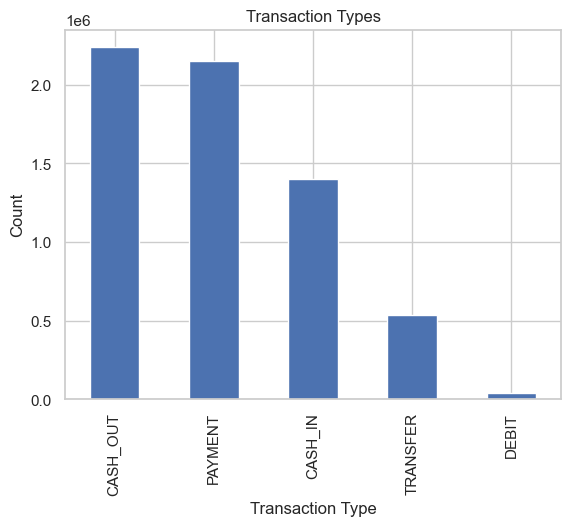

In [14]:
df['type'].value_counts().plot(kind='bar',title='Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

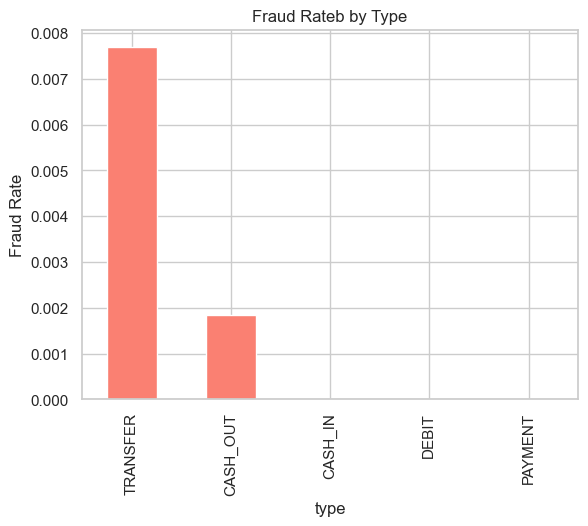

In [ ]:
fraud_by_type=df.groupby('type')["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar',title='Fraud Rate by Type',color='salmon')
plt.ylabel('Fraud Rate')
plt.show()

In [16]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

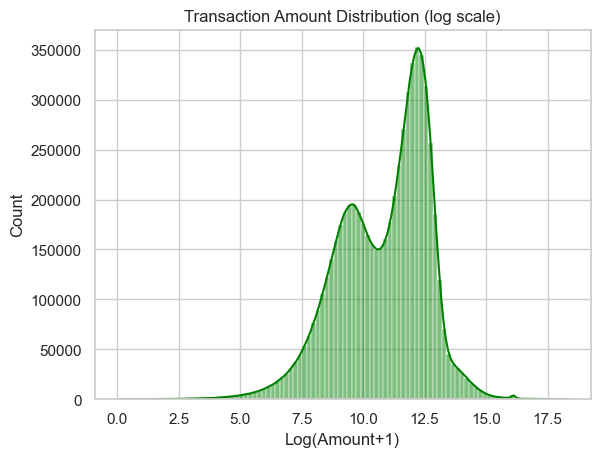

In [17]:
sns.histplot(np.log1p(df['amount']),bins=100,kde=True,color='green') #log1p=log(1+x),used when the value is close to zero
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel('Log(Amount+1)')
plt.ylabel('Count')
plt.show()

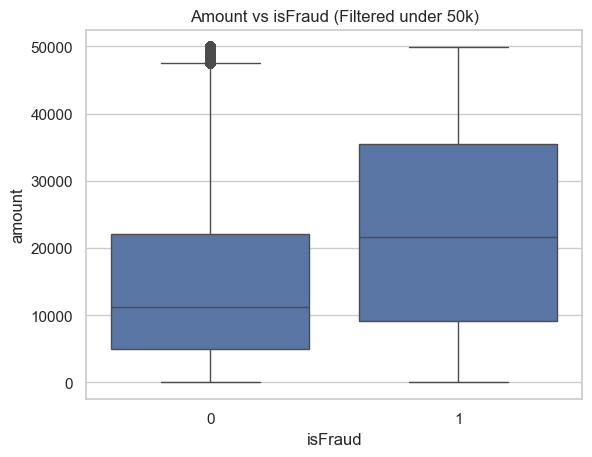

In [18]:
sns.boxplot(data=df[df['amount']<50000],x='isFraud',y='amount')
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [19]:
df['balanceDiffOrig']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balanceDiffDest']=df['newbalanceDest']-df['oldbalanceDest']

In [20]:
(df['balanceDiffOrig']<0).sum()

np.int64(1399253)

In [21]:
(df['balanceDiffDest']< 0).sum()

np.int64(1238864)

In [22]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


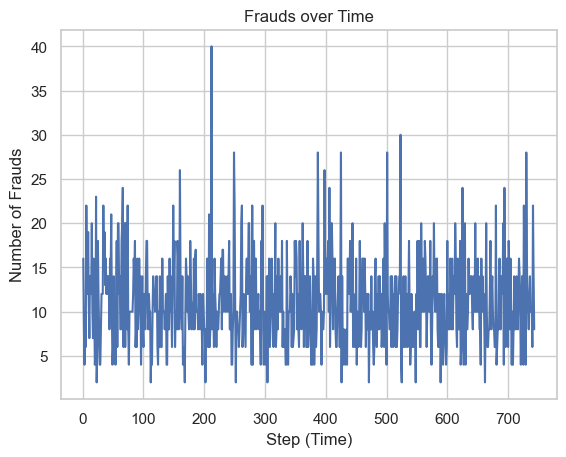

In [23]:
frauds_per_step=df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index,frauds_per_step.values,label='Frauds per Step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Frauds')
plt.title("Frauds over Time")
plt.grid(True)
plt.show()

In [24]:
df.drop(columns="step",inplace=True)

In [25]:
top_senders=df['nameOrig'].value_counts().head(10)

In [26]:
top_receivers=df['nameDest'].value_counts().head(10)

In [27]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [28]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [29]:
fraud_users=df[df['isFraud']==1]['nameOrig'].value_counts().head(10)

In [30]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [31]:
fraud_types=df[df['type'].isin(['TRANSFER','CASH_OUT'])]

In [32]:
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

Text(0.5, 1.0, 'Fraud Distribution in Transfer and Cash Out')

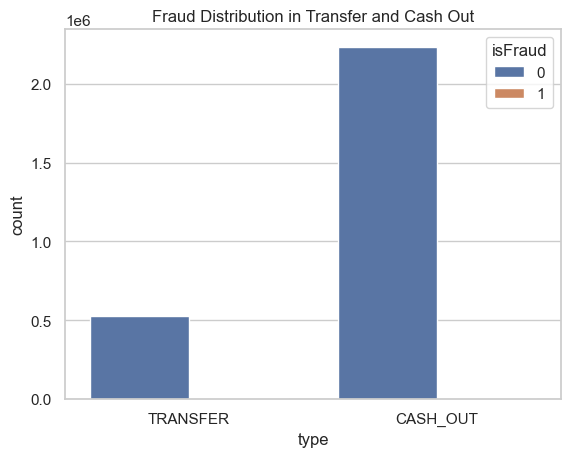

In [33]:
sns.countplot(data=fraud_types,x='type',hue='isFraud')
plt.title("Fraud Distribution in Transfer and Cash Out")

In [34]:
corr=df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()

In [35]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


Text(0.5, 1.0, 'Correlation Matrix')

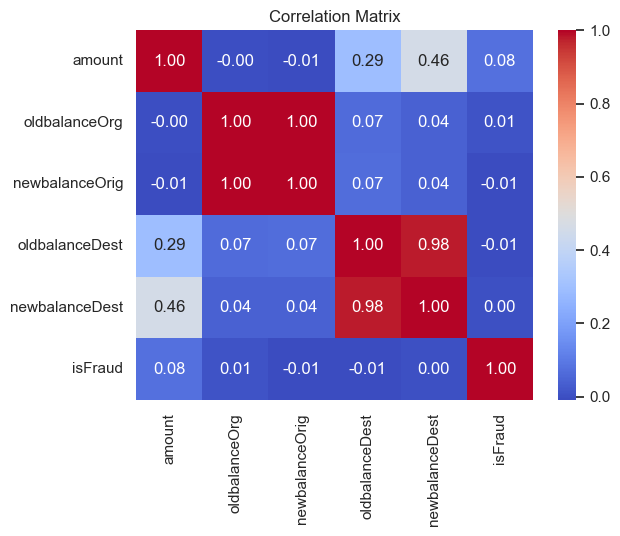

In [36]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')

In [37]:
zero_after_transfer=df[(df['oldbalanceOrg']>0) &
     (df['newbalanceOrig']==0) &
     (df['type'].isin(['TRANSFER','CASH_OUT']))
]

In [38]:
len(zero_after_transfer)

1188074

In [39]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline #training model and transformation oprtn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [41]:
df_model=df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)

In [42]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [43]:
categorical=['type']
numerical=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [44]:
x = df.drop("isFraud", axis=1)
y = df["isFraud"]

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [46]:
preprocessor=ColumnTransformer(
    transformers= [
       ("num",StandardScaler(),numerical),
       ("cat",OneHotEncoder(handle_unknown='ignore'),categorical)
    ], 
    remainder="passthrough"
)


In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)


In [48]:
print(type(x_train))

<class 'pandas.core.frame.DataFrame'>


In [49]:
print(x_train.head())
print(x_train.columns)
print(type(x_train))

             type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2408104   CASH_IN    26771.98  C1757325207       27521.00        54292.98   
662430   CASH_OUT   344879.65  C1581387557           0.00            0.00   
496595   TRANSFER  1862607.84    C40667532           0.00            0.00   
5053741   PAYMENT    37739.35   C650378192       66684.93        28945.58   
755621   CASH_OUT   376055.13  C1711774391       22501.00            0.00   

            nameDest  oldbalanceDest  newbalanceDest  isFlaggedFraud  \
2408104  C1063361489      7175503.03      7148731.05               0   
662430   C1423956695      3731846.57      4076726.22               0   
496595   C2074118913      3329828.01      4913631.27               0   
5053741  M1029189176            0.00            0.00               0   
755621    C109054029       182350.43       558405.55               0   

         balanceDiffOrig  balanceDiffDest  
2408104        -26771.98        -26771.98  
662430          

In [50]:
df = df.drop(['nameOrig','nameDest'],inplace=True, axis=1)

In [51]:
x = df[['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']]
y = df['isFraud']

TypeError: 'NoneType' object is not subscriptable

In [ ]:
pipeline=Pipeline([
    ("prep",preprocessor),
    ("clf",RandomForestClassifier(class_weight="balanced"))

])
pipeline.fit(x_train, y_train)

In [ ]:
y_pred=pipeline.predict(x_test)

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
confusion_matrix(y_test,y_pred)

In [ ]:
pipeline.score(x_test,y_test)

In [ ]:
import pickle
pickle.dump(pipeline,open("fraud_detection_pipeline.pkl",'wb'))
